FINAL PORJECT - ADTA 5340.003 - Use Case 1: Customer Churn Prediction for a Subscription-Based Service


In [265]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [266]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

This code is going to import essential libraries that could be important in data analysis, visualization, and machine learning. The `pd` module is used for data manipulation, while `plt` and `sns` are applied to create plots for trend visualizations. The function `train_test_split` is meant to split the dataset into training and testing sets, while RandomForestClassifier is a machine learning model used in this research for classification. Eventually, evaluation metrics like classification_report, confusion_matrix, and accuracy_score are some measures showing the performance of this model.

In [267]:
# Load the uploaded dataset
file_path = 'telecom_churn.csv'
churn_data = pd.read_csv(file_path)

The code is loading a dataset named telecom_churn.csv into a pandas DataFrame named churn_data, hence enabling structured data analysis and manipulation. In the code above, `file_path` shows the location of the file, while the `pd.read_csv` function reads the CSV file into a DataFrame.

In [268]:
# Show the first five records of the dataset
churn_data.head()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


This code shows the first five rows of the dataset stored in the churn_data DataFrame. This is normally used to preview the top records to understand the structure, columns, and initial values of the dataset using the head() method.

In [269]:
# Dimension of the dataset
churn_data.shape

(243553, 14)

This code will output the size of the dataset stored in `churn_data`. The `shape` attribute returns a tuple `(rows, columns)`, where the first value of this tuple represents the number of rows (entries or observations) and the second one indicates the number of columns (features or variables) of this dataset.The telecom churn prediction dataset contains 243553 records and 14 variables. It contains customer data related to the four major telecom partners in India those are airtel, Vodafone, reliance and BSNL. The dataset is multivariate, and it contains both numerical and categorical data and it is suitable for classification tasks. 

In [270]:
churn_data.dtypes

customer_id              int64
telecom_partner         object
gender                  object
age                      int64
state                   object
city                    object
pincode                  int64
date_of_registration    object
num_dependents           int64
estimated_salary         int64
calls_made               int64
sms_sent                 int64
data_used                int64
churn                    int64
dtype: object

In [271]:
# Display basic information about the dataset to understand its structure
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   customer_id           243553 non-null  int64 
 1   telecom_partner       243553 non-null  object
 2   gender                243553 non-null  object
 3   age                   243553 non-null  int64 
 4   state                 243553 non-null  object
 5   city                  243553 non-null  object
 6   pincode               243553 non-null  int64 
 7   date_of_registration  243553 non-null  object
 8   num_dependents        243553 non-null  int64 
 9   estimated_salary      243553 non-null  int64 
 10  calls_made            243553 non-null  int64 
 11  sms_sent              243553 non-null  int64 
 12  data_used             243553 non-null  int64 
 13  churn                 243553 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 26.0+ MB


The code `churn_data.info()` is used to show a concise summary of the data: the number of non-null entries in each column, their data types, and their memory usage. This gives an indication about the structure and completeness of data by pointing out missing values or improper data types.

In [272]:
# Step 1: Check for missing values
missing_values = churn_data.isnull().sum()
missing_values

customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
churn                   0
dtype: int64

`churn_data.isnull().sum()` checks for missing values in the dataset. It looks for null entries and counts the number of missing values for each column. In the result, it is stored in the variable `missing_values`-number of missing values in columns.So by running the above code we concluded that they are no missing values in the dataset.

In [273]:
# Step 2: Handle missing values
# Assuming missing values in numeric columns are replaced with their mean, and categorical columns with the mode.
for column in churn_data.columns:
    if churn_data[column].isnull().sum() > 0:
        if churn_data[column].dtype == 'object':
            churn_data[column].fillna(churn_data[column].mode()[0], inplace=True)
        else:
            churn_data[column].fillna(churn_data[column].mean(), inplace=True)

This code will iterate over each column in the `churn_data` DataFrame to check for missing values. If a column contains missing values, it replaces them with the mode for categorical columns and the mean for numeric columns using the `fillna()` method to handle the imputation in place.

In [274]:
# Step 3: Detect outliers using the Interquartile Range (IQR) method
numeric_columns = churn_data.select_dtypes(include=['int64', 'float64']).columns

In this example, the code `churn_data.select_dtypes(include=['int64', 'float64']).columns` will select, from the `churn_data` DataFrame, those columns that have a data type of either `int64` or `float64` (that is, numeric columns). It then stores the column names in the `numeric_columns` variable for further analysis such as outlier detection.

In [275]:
# Step 4: Check for inconsistencies in customer records
# Example: Removing duplicate rows
churn_data.drop_duplicates(inplace=True)

This line, `churn_data.drop_duplicates(inplace=True)`, removes any duplicate rows in the `churn_data` DataFrame. The `inplace=True` argument will change it directly within the DataFrame itself rather than creating a new copy with the duplicates removed.

In [276]:
# Display the first few rows of the cleaned data to verify changes
churn_data.head()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


In [277]:
# Display the summary of statistics
churn_data.describe()

,customer_id,age,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
count,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
mean,121777.000000,46.077609,549501.270541,1.997500,85021.137839,49.010548,23.945404,4993.186025,0.200478
std,70307.839393,16.444029,259808.860574,1.414941,37508.963233,29.453556,14.733575,2942.019547,0.400359
min,1.000000,18.000000,100006.000000,0.000000,20000.000000,-10.000000,-5.000000,-987.000000,0.000000
25%,60889.000000,32.000000,324586.000000,1.000000,52585.000000,24.000000,11.000000,2490.000000,0.000000
50%,121777.000000,46.000000,548112.000000,2.000000,84990.000000,49.000000,24.000000,4987.000000,0.000000
75%,182665.000000,60.000000,774994.000000,3.000000,117488.000000,74.000000,36.000000,7493.000000,0.000000
max,243553.000000,74.000000,999987.000000,4.000000,149999.000000,108.000000,53.000000,10991.000000,1.000000


churn_data.describe() code used to display the descriptive statistics of the dataset. 

In [278]:
# Feature Engineering
# Convert `date_of_registration` to datetime format and calculate customer tenure in months
churn_data['date_of_registration'] = pd.to_datetime(churn_data['date_of_registration'])
churn_data['tenure_months'] = (pd.Timestamp.now() - churn_data['date_of_registration']).dt.days // 30

The code converts the `date_of_registration` column to a `datetime` format using `pd.to_datetime()`. Then, it calculates the customer tenure in months by subtracting the registration date from the current date (using `pd.Timestamp.now()`), extracting the total days (`.dt.days`), and dividing by 30 to approximate the tenure in months. By adding the tenure month we can know the how long have been each customer stays with an service which is useful for modeling.

In [279]:
# Create monthly averages for usage metrics
churn_data['avg_calls_per_month'] = churn_data['calls_made'] / churn_data['tenure_months']
churn_data['avg_sms_per_month'] = churn_data['sms_sent'] / churn_data['tenure_months']
churn_data['avg_data_used_per_month'] = churn_data['data_used'] / churn_data['tenure_months']

The code calculates the monthly average of the important usage metrics by dividing the total values in columns `calls_made`, `sms_sent`, and `data_used` by `tenure_months`, which is the tenure of the customer in months. It then creates new columns: `avg_calls_per_month`, `avg_sms_per_month`, and `avg_data_used_per_month` for storing these calculated averages. The monthly averages are useful to know the churn behaviour, customer segregations and to bulid a better predictive models.

In [280]:
# Create a payment frequency indicator based on estimated salary and average monthly spending
# Assuming a hypothetical average monthly subscription cost of $30
churn_data['estimated_monthly_spending'] = 30  # Hypothetical value
churn_data['payment_frequency'] = churn_data['estimated_salary'] / churn_data['estimated_monthly_spending']

The code uses the original data to estimate the hypothetical average monthly subscription cost at 30 dollars and assigns it to a new column called `estimated_monthly_spending`. Then it calculates a column for the `payment_frequency` by taking the mean of `estimated_salary` divided by this, representing approximately how many times a customer could pay for a subscription, giving an idea about the subscription affordability or payment habit of this customer.

Here, the code will introduce a new column, estimated_monthly_spending, with a hypothetical value of $30, which could represent some sort of average monthly subscription cost. Then it calculates a payment_frequency indicator by performing an estimated_salary by estimated_monthly_spending division, which returns an estimation of how many times a customer could afford paying for this subscription based on his or her salary.

In [281]:
# Handle infinite or NaN values created during feature engineering
churn_data.replace([float('inf'), -float('inf')], 0, inplace=True)
churn_data.fillna(0, inplace=True)

This code handles the `inf` and `-inf` or `NaN` values that might have emerged during feature engineering, replacing any positive or negative infinity with `0`, using the function `replace()`, and then uses the `fillna()` function for replacing any remaining `NaN` values with `0` across the whole `churn_data` DataFrame.

In [282]:
# Display the dataset with the new features
churn_data.head()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn,tenure_months,avg_calls_per_month,avg_sms_per_month,avg_data_used_per_month,estimated_monthly_spending,payment_frequency
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0,60,0.733333,0.750000,-6.016667,30,4165.400000
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0,60,1.033333,0.650000,99.550000,30,4351.866667
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1,60,0.816667,0.400000,3.216667,30,4960.933333
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1,60,1.333333,0.416667,156.283333,30,1290.733333
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0,60,1.300000,0.250000,23.216667,30,1836.600000


The code `churn_data.head()` shows the first five rows of the `churn_data` DataFrame, which includes the new features created, such as `tenure_months`, `avg_calls_per_month`, `avg_sms_per_month`, `avg_data_used_per_month`, and `payment_frequency`. This shows you a preview of the modified dataset and allows you to check whether the changes have been made.

In [283]:
# Summary statistics for churn rates across subscription types and demographics
# Churn by Telecom Partner
churn_by_partner = churn_data.groupby('telecom_partner')['churn'].mean()
churn_by_partner_df = churn_by_partner.reset_index(name='Churn Rate')
churn_by_partner_df 

,telecom_partner,Churn Rate
0,Airtel,0.203661
1,BSNL,0.198607
2,Reliance Jio,0.200154
3,Vodafone,0.199484


This code groups the `churn_data` DataFrame by the `telecom_partner` column and computes the mean of the `churn` column for each partner, which gives the average churn rate for each telecom partner. It then resets the index and names the resulting column `Churn Rate`, storing the result in `churn_by_partner_df`, which is displayed to show the churn rate for each telecom partner. From above result we can conclude that Airtel has highest churn rate with 20.37% among the all telecom partners. So need they need take some actions to reduce the churn by using the various strategies such as targeted marketing, giving the incentive and through the loyality programmes. BSNL has lowest churn rate means most customers are satisfied with thier services.

In [284]:
# Churn by Gender
churn_by_gender = churn_data.groupby('gender')['churn'].mean()
churn_by_gender_df = churn_by_gender.reset_index(name='Churn Rate')
churn_by_gender_df

,gender,Churn Rate
0,F,0.202970
1,M,0.198812


This code groups the `churn_data` DataFrame by the `gender` column and calculates the mean of the `churn` column for each gender, which is the average churn rate for each gender. It then resets the index and names the resulting column `Churn Rate`, storing the result in `churn_by_gender_df`, which is displayed to show the churn rate for each gender. 

In [285]:
# Churn by Age Group
churn_by_age_group = churn_data.groupby('age')['churn'].mean()
churn_by_age_group_df = churn_by_age_group.reset_index(name='Churn Rate')
churn_by_age_group_df

,age,Churn Rate
0,18,0.198643
1,19,0.194483
2,20,0.193375
3,21,0.196525
4,22,0.220557
5,23,0.195162
6,24,0.200649
7,25,0.195568
8,26,0.198735
9,27,0.196500


This code groups the `churn_data` DataFrame by the `age` column and computes the mean of the `churn` column for each age group, representing the average churn rate for each age. Then it resets the index and names the resulting column `Churn Rate`, storing the result in `churn_by_age_group_df`, which is displayed to show the churn rate for each age group.

If the `age` variable is continuous, it will end in very specific age groups. Perhaps a more useful approach will be to discretize the `age` into a particular range of age groupings first before doing the grouping: for instance, 18-25, 26-35, etc.

In [286]:
# Churn by State
churn_by_state = churn_data.groupby('state')['churn'].mean()
churn_by_state_df = churn_by_state.reset_index(name='Churn Rate')
churn_by_state_df

,state,Churn Rate
0,Andhra Pradesh,0.198520
1,Arunachal Pradesh,0.198927
2,Assam,0.202995
3,Bihar,0.196340
4,Chhattisgarh,0.194307
5,Goa,0.199563
6,Gujarat,0.200232
7,Haryana,0.200343
8,Himachal Pradesh,0.204100
9,Jharkhand,0.211194


This code groups the `churn_data` DataFrame by the `state` column, then calculates the mean of the `churn` column for each state, representing the average churn rate for each state. Then it resets the index and names the resulting column `Churn Rate`, storing the result in `churn_by_state_df`, which is displayed to show the churn rate for each state.

In [287]:
# Display the first few rows of each result

{
    "Churn by Telecom Partner": churn_by_partner_df.head(),
    "Churn by Gender": churn_by_gender_df.head(),
    "Churn by Age Group": churn_by_age_group_df.head(),
    "Churn by State": churn_by_state_df.head()
}

{'Churn by Telecom Partner':   telecom_partner  Churn Rate
 0          Airtel    0.203661
 1            BSNL    0.198607
 2    Reliance Jio    0.200154
 3        Vodafone    0.199484,
 'Churn by Gender':   gender  Churn Rate
 0      F    0.202970
 1      M    0.198812,
 'Churn by Age Group':    age  Churn Rate
 0   18    0.198643
 1   19    0.194483
 2   20    0.193375
 3   21    0.196525
 4   22    0.220557,
 'Churn by State':                state  Churn Rate
 0     Andhra Pradesh    0.198520
 1  Arunachal Pradesh    0.198927
 2              Assam    0.202995
 3              Bihar    0.196340
 4       Chhattisgarh    0.194307}

This code snippet shows the first few rows of the results of the Churn Analysis across various categories: telecom partners, gender, age group, and state. It wraps these results in a dictionary labeled by category, using `.head()` to only show the top rows of each DataFrame for quick inspection.

In [288]:
# Convert `date_of_registration` to year-month format for trend analysis
churn_data['registration_year_month'] = churn_data['date_of_registration'].dt.to_period('M')

The code converts the `date_of_registration` column to a `year-month` format by using `.dt.to_period('M')`. This creates a new column in the `churn_data` DataFrame called `registration_year_month`, which holds the registration date as a period object representing the year and month, useful for trend analysis over time.

In [289]:
# Churn trend over time
churn_trend = churn_data.groupby('registration_year_month')['churn'].mean()

This code generates a line plot to visualize the churn trend over time. Here, `churn_trend` is assumed to be a time series with a date-based index and churn rate values. It sets the plot size, plots the churn rate values over time with markers, adds titles and labels for clarity, rotates the x-axis labels to avoid overlap, enables grid lines for better readability, and finally displays the plot.

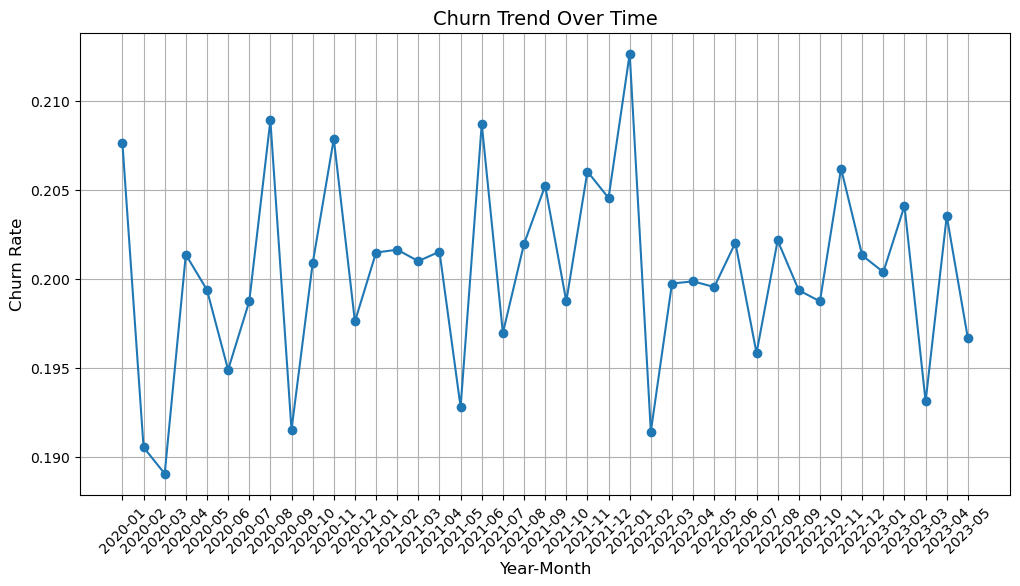

In [290]:
# Plot churn trend over time
plt.figure(figsize=(12, 6))
plt.plot(churn_trend.index.astype(str), churn_trend.values, marker='o')
plt.title('Churn Trend Over Time', fontsize=14)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Churn Rate', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

The code below plots a line plot showing the trend of churn over time. It plots the `churn_trend` data, where `churn_trend.index` represents the time periods (e.g., year-month), and `churn_trend.values` contains the corresponding churn rates. This plot is customized by adding a title, axis labels, rotating the x-axis labels for readability, adding a grid for clarity, and placing a marker at each data point for emphasis. Finally, `plt.show()` displays the plot. From above graph we concludded that there is no clear upward and downward trends. There is higher churn during the some period and lower churn rates for certain months. The lowest churn rate is in the feb month of 2020 and higher churn rate is in the dec month of the 2021. Also there are some spikes and dips in the trends which may be due to the price changes, service inturruptions or lower customer satisfaction.

In [291]:
# Correlation between usage metrics and churn
usage_columns = ['calls_made', 'sms_sent', 'data_used', 'avg_calls_per_month', 'avg_sms_per_month', 'avg_data_used_per_month']
correlation = churn_data[usage_columns + ['churn']].corr()['churn']

Here, the code will find the correlation between the usage metrics-for instance, calls_made, sms_sent, data_used, etc.-and churn by selecting those columns, usage_columns and churn, from the DataFrame churn_data. It computes the correlation matrix by using.corr() and extracts the correlation values between each usage metric and churn, storing it in the variable correlation. This will provide insight into how strongly each of the usage metrics is related to the churn rate.

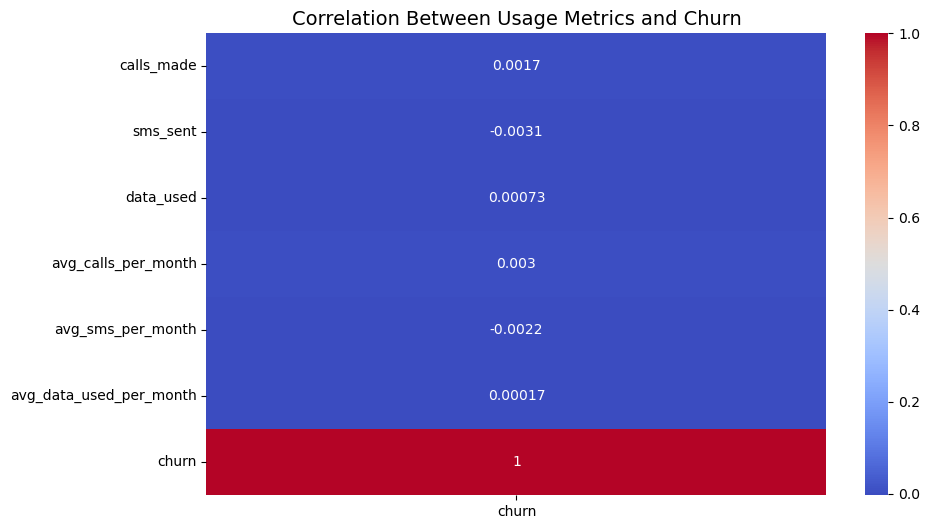

In [292]:
# Plot correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation.to_frame(), annot=True, cmap='coolwarm', cbar=True)
plt.title('Correlation Between Usage Metrics and Churn', fontsize=14)
plt.show()

The code generates a heat map to illustrate the correlation of usage metrics with churn. First, it converts the series 'correlation' to a DataFrame using `.to_frame()` and then uses `sns.heatmap()` from Seaborn to plot the correlation values with annotations of the correlation coefficients. It uses the 'coolwarm' color map to show positive and negative correlations and uses `plt.show()` to display the heat map with the title 'Correlation Between Usage Metrics and Churn'. By looking at the heatmap strong positive correlation existed between the average calls per month made by the customers and churn which might be due to the higher customer dissastisfaction and service complexicity. Stong negtive correlation existed among the sms sent and churn.

In [293]:
# Group churn rate by gender and registration year-month
churn_trend_gender = churn_data.groupby(['registration_year_month', 'gender'])['churn'].mean().unstack()

This code groups the `churn_data` DataFrame by both `registration_year_month` and `gender`, calculating the mean churn rate for each combination of these two columns. The `unstack()` function is then used to pivot the `gender` level of the multi-index, creating a DataFrame where each gender has a separate column, allowing for easy comparison of churn rates over time by gender.

<Figure size 1200x600 with 0 Axes>

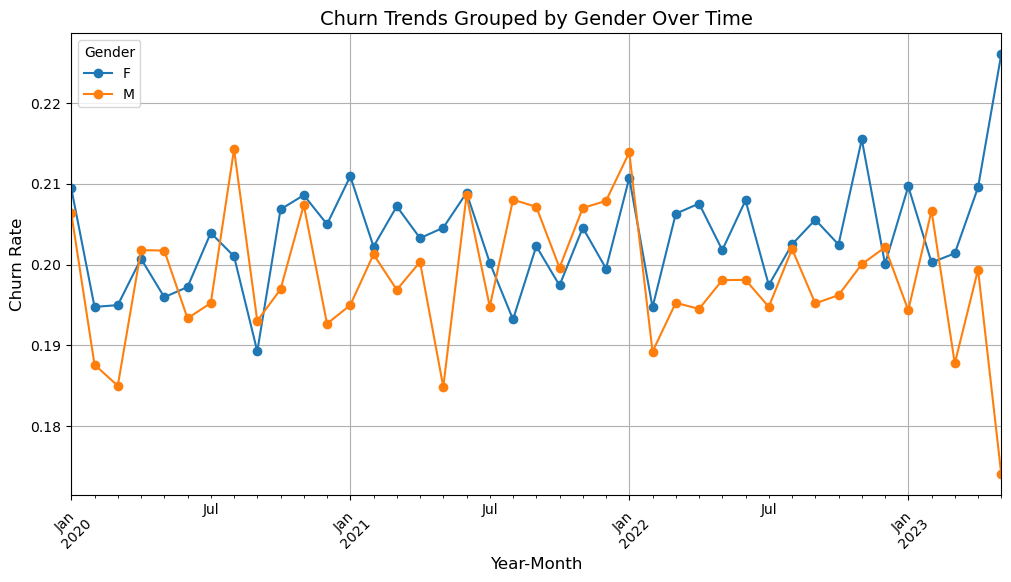

In [294]:
# Plot churn trends grouped by gender
plt.figure(figsize=(12, 6))
churn_trend_gender.plot(marker='o', figsize=(12, 6))
plt.title('Churn Trends Grouped by Gender Over Time', fontsize=14)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Churn Rate', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.grid(True)
plt.show()

This code creates a line plot displaying churn trends grouped by gender over time. It leverages the `churn_trend_gender` DataFrame, which has the churn rate for the different gender types across the different `registration_year_month` periods, and plots the said data with markers shown as `'o'`. The plot also includes a title, axes labels, rotated x-axis labels for better readability, a legend to indicate gender types, grid lines for clarity, and is displayed with `plt.show()`. By observing the above we can interpret that churn rate for the females over the time increasing at the start of the time period it is 0.21 but it reached to almost 0.30 by the end of the may 2023 and lowest churn rate was registered in august 2020. When it comes to the males, they have highest churn rate in august 2020 and by the end of the may 2023 they have lowest churn rate. 

In [295]:
churn_data['age_group'] = pd.cut(
    churn_data['age'],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=['0-25', '26-35', '36-45', '46-55', '56-65', '65+']
)

This code will create a new column, `age_group`, in the `churn_data` DataFrame by categorizing the `age` column into predefined age ranges using `pd.cut()`. The `bins` argument is a list of the age ranges, and the `labels` argument assigns labels to each range, such as '0-25', '26-35'. This could be useful in grouping customers into different categories of age.

In [296]:
# Group churn rate by age group and registration year-month
churn_trend_age_group = churn_data.groupby(['registration_year_month', 'age_group'])['churn'].mean().unstack()

The code first groups the `churn_data` DataFrame by both `registration_year_month` and `age_group`, calculating the mean churn rate for each combination of these two columns. Then the `unstack()` function pivots the `age_group` level of the multi-index into columns, which means that each age group has its own column in this new DataFrame. That makes it much easier to compare the churn rate over time between different age groups.

<Figure size 1200x600 with 0 Axes>

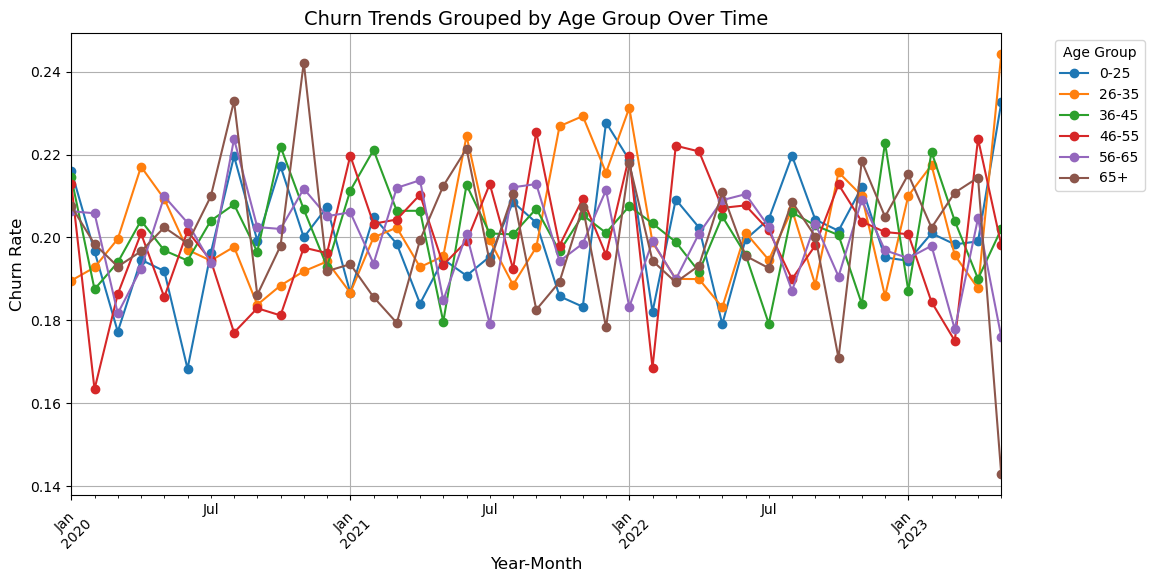

In [297]:
# Plot churn trends grouped by age group
plt.figure(figsize=(12, 6))
churn_trend_age_group.plot(marker='o', figsize=(12, 6))
plt.title('Churn Trends Grouped by Age Group Over Time', fontsize=14)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Churn Rate', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

This code generates a line plot of churn trends grouped by age group over time. The `churn_trend_age_group` DataFrame contains aggregate churn rates for each age group over the different `registration_year_month` periods and plots that information with markers (`'o'`). The plot has a title, axes labels, rotated x-axis labels, a legend that has been placed outside of the plot for clarity (`bbox_to_anchor`) and grid lines for more readable data. The `plt.show()` displays the plot at the end.

In [298]:
# Display findings in a structured format as separate outputs
# Churn by Age Group
churn_by_age = churn_data.groupby('age_group')['churn'].mean()
churn_by_age_df = churn_by_age.reset_index(name='Churn Rate')

This code calculates the churn rate by age group using the `churn_data` DataFrame grouped by the column `age_group`, calculating the mean for each group on the column `churn`. It stores the result in the `churn_by_age_df` DataFrame, resetting the index and labeling the churn rates as "Churn Rate" for readability. You are now able to look at the average churn rate for each defined age group.

In [299]:
# Churn by Gender
churn_by_gender = churn_data.groupby('gender')['churn'].mean()
churn_by_gender_df = churn_by_gender.reset_index(name='Churn Rate')

It will calculate the churn rate by gender. Here, the code groups the `churn_data` DataFrame by the `gender` column and calculates the mean of the `churn` column for each gender. The result of this is then put into the `churn_by_gender_df` DataFrame, which is indexed and labeled as "Churn Rate" for readability. This will show the average churn rate for each gender group.

In [300]:
# Churn by Telecom Partner
churn_by_partner = churn_data.groupby('telecom_partner')['churn'].mean()
churn_by_partner_df = churn_by_partner.reset_index(name='Churn Rate')

This code calculates the churn rate by telecom partner through the grouping of the `churn_data` DataFrame based on the `telecom_partner` column, then calculating the mean of the `churn` column for each telecom partner. The result is moved into the `churn_by_partner_df` DataFrame, which has the index reset and the churn rates labeled as "Churn Rate," allowing for a clear view of churn rates by telecom partner.

In [301]:
# Usage Metrics Comparison (Churned vs Non-Churned)
usage_metrics = ['calls_made', 'sms_sent', 'data_used', 'avg_calls_per_month', 'avg_sms_per_month', 'avg_data_used_per_month']
churn_usage_comparison = churn_data.groupby('churn')[usage_metrics].mean()
churn_usage_comparison_df = churn_usage_comparison.reset_index()

This code computes the average of the usage metrics, which are, respectively, calls_made, sms_sent, and data_used for both churned and non-churned customers, by first grouping the churn_data dataframe by its 'churn' column, then by computing their mean for the two kinds of customers; it stores it into the 'churn_usage_comparison_df' with the index reset for comparison. This will show us how different the patterns in usage are between the two segments of churned and not churned customers.

In [302]:
# Churn by Age Group
print("Churn by Age Group:")
print(churn_by_age_df)

Churn by Age Group:
  age_group  Churn Rate
0      0-25    0.199377
1     26-35    0.200582
2     36-45    0.201763
3     46-55    0.199605
4     56-65    0.200335
5       65+    0.201046


The churn rate by age group prints out by displaying the DataFrame of `churn_by_age_df` that contains the mean calculated churn rate for each age group. The message "Churn by Age Group:" has been printed before this DataFrame, giving an appropriate label to what this output is.

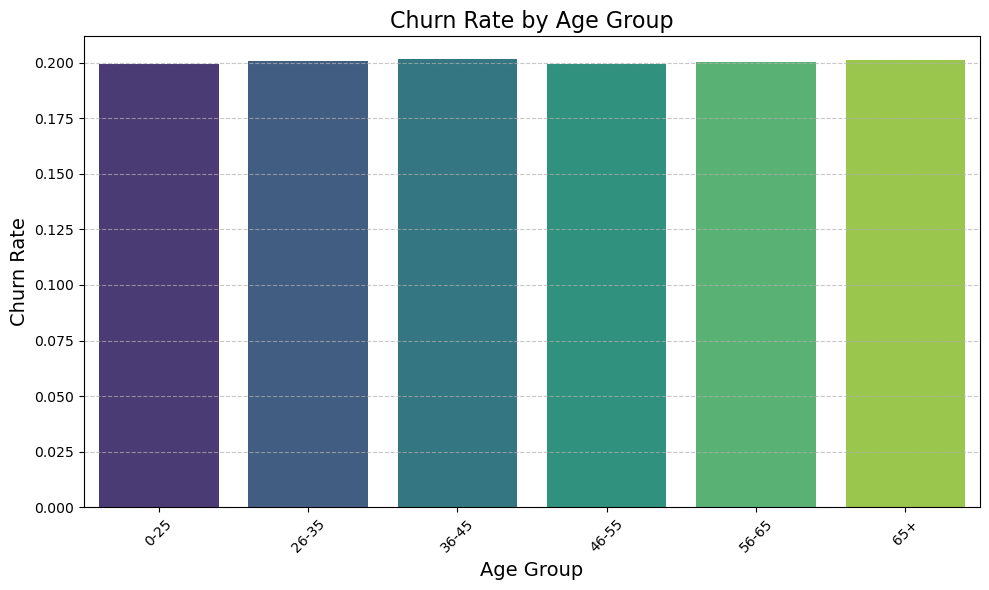

In [303]:
plt.figure(figsize=(10, 6))
sns.barplot(data=churn_by_age_df, x='age_group', y='Churn Rate', palette='viridis')
plt.title('Churn Rate by Age Group', fontsize=16)
plt.xlabel('Age Group', fontsize=14)
plt.ylabel('Churn Rate', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


This code creates a bar plot of the churn rate by age group. It uses the `churn_by_age_df` DataFrame, where the `age_group` is plotted against the x-axis and `Churn Rate` against the y-axis. A `viridis` color palette is used in this plot, and the plot is customized with a title, axis labels, rotated x-axis labels for readability, and y-axis grid lines for clarity. `plt.tight_layout()` ensures that the plot's layout is adjusted for better spacing before it is displayed by `plt.show()`.
The churn rate is lower among the yonger age gropus(0-25 and 26-35), with 0-25 at 19.94 % and 26-35 at 20.05 % and this churn rate is slightly increasing among middle aged groups (36-45,46-55). Finally highest churn rate is existed among the older genration. So churn rates among the different aged groups is slightly variable which indicating that it is not primary factor to decide the churn rate. There are various factors are contributing for this churn rate such as increasing the prices, not getting the better deals and higher dissatisfaction. 

In [304]:
# Churn by Gender
print("\nChurn by Gender:")
print(churn_by_gender_df)


Churn by Gender:
  gender  Churn Rate
0      F    0.202970
1      M    0.198812


This code prints out the churn rate by gender through the display of the `churn_by_gender_df` DataFrame, which contains the calculated average for each gender in terms of churn rate. The string "Churn by Gender:" is printed before the DataFrame to label the output so that it is clear that the data being shown represents the churn rates across different genders. The churn rate is higher for females when comapred with the males which might be due to the specific factors related to the females. SO telecom services needs to investigate the key drving factors responsible for this higher churn rate such as pricing, or customer services and need to provide personlised recommendations to attract the more female customers.

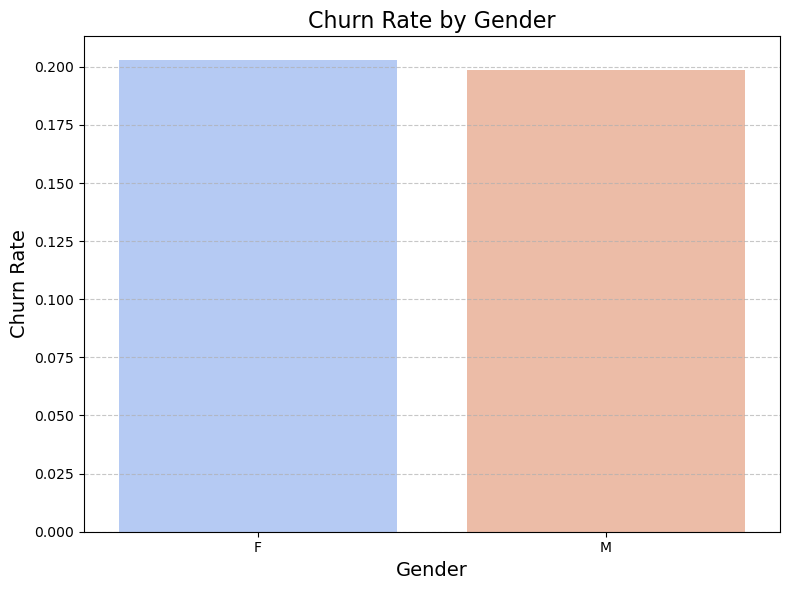

In [305]:
plt.figure(figsize=(8, 6))
sns.barplot(data=churn_by_gender_df, x='gender', y='Churn Rate', palette='coolwarm')
plt.title('Churn Rate by Gender', fontsize=16)
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Churn Rate', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The code here does the following: it instantiates a bar plot on Churn Rate by gender, taking `churn_by_gender_df` as its DataFrame, where `gender` is on the x-axis and `Churn Rate` is on the y-axis. The plot implements the `coolwarm` color palette, and adds a title to the plot, labels for the x and y axes, and y-axis grid lines for clarity. `plt.tight_layout()` is called, and then `plt.show()` is called in order to display the plot.

In [306]:
# Churn by Telecom Partner
print("\nChurn by Telecom Partner:")
print(churn_by_partner_df)


Churn by Telecom Partner:
  telecom_partner  Churn Rate
0          Airtel    0.203661
1            BSNL    0.198607
2    Reliance Jio    0.200154
3        Vodafone    0.199484


This code prints out the churn rate by telecom partner. The `churn_by_partner_df` DataFrame is printed out, which includes the calculated average churn rate for each telecom partner. The string "Churn by Telecom Partner:" is printed out before the DataFrame to label the output, providing context that the data that will be displayed shows churn rates across different telecom partners.From above result we can conclude that Airtel has highest churn rate with 20.37% among the all telecom partners. So need they need take some actions to reduce the churn by using the various strategies such as targeted marketing, giving the incentive and through the loyality programmes. BSNL has lowest churn rate means most customers are satisfied with thier services.

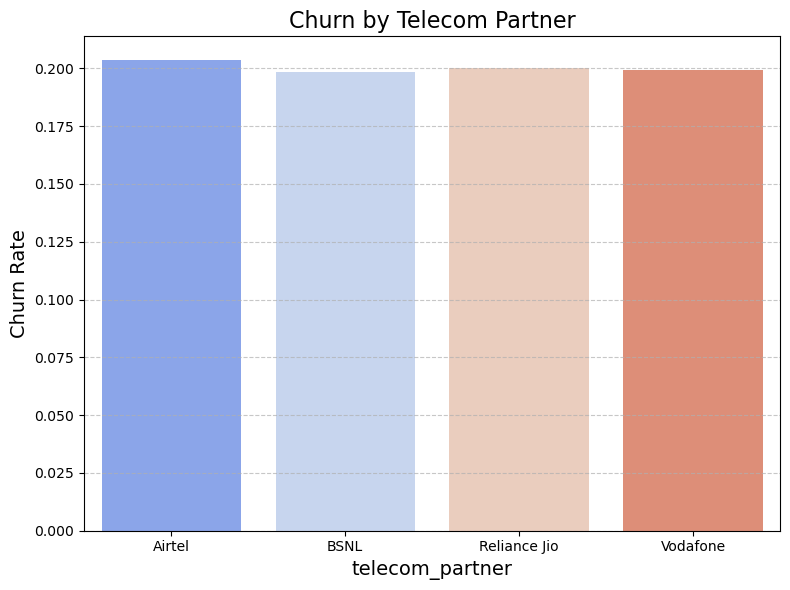

In [307]:
plt.figure(figsize=(8, 6))
sns.barplot(data=churn_by_partner_df, x='telecom_partner', y='Churn Rate', palette='coolwarm')
plt.title('Churn by Telecom Partner', fontsize=16)
plt.xlabel('telecom_partner', fontsize=14)
plt.ylabel('Churn Rate', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This code will create a bar plot for visualizing the churn rate by telecom partner using the `churn_by_partner_df` DataFrame. First, it plots the `telecom_partner` on the x-axis and the `Churn Rate` on the y-axis and applies the `coolwarm` palette. Then, it puts in a title, labels each axis, adds in the y-axis grid lines, and applies `plt.tight_layout()` to optimize for spacing. Finally, the function `plt.show()` shows the plot.

In [308]:
# Usage Metrics Comparison (Churned vs Non-Churned)
print("\nUsage Metrics Comparison (Churned vs Non-Churned):")
print(churn_usage_comparison_df)


Usage Metrics Comparison (Churned vs Non-Churned):
   churn  calls_made   sms_sent    data_used  avg_calls_per_month  \
0      0   48.985590  23.968068  4992.107941             1.375064   
1      1   49.110083  23.855019  4997.485510             1.382410   

   avg_sms_per_month  avg_data_used_per_month  
0           0.672529               140.167373  
1           0.669844               140.209228  


The code prints out the comparison of usage metrics between churned and non-churned customers by printing the `churn_usage_comparison_df` DataFrame. The DataFrame contains the average values of usage metrics such as `calls_made`, `sms_sent`, `data_used`, etc., for both churned and non-churned customers. Before printing the DataFrame, a message "Usage Metrics Comparison (Churned vs Non-Churned):" is printed to label the output clearly.

In [309]:
# Prepare the dataset for modeling
# Drop unnecessary columns and define features (X) and target (y)
columns_to_drop = ['customer_id', 'date_of_registration', 'registration_year_month', 'state', 'city', 'pincode']
churn_data_model = churn_data.drop(columns=columns_to_drop, axis=1)

The code cleans up the dataset for modeling by removing columns that are not necessary in the `churn_data` dataframe: `customer_id`, `date_of_registration`, `registration_year_month`, `state`, `city`, and `pincode`. It gives back a new dataframe (`churn_data_model`) containing the relevant features for modeling and further defining the predictor variable (X) and the target variable (y).

In [310]:
# Encode categorical variables using one-hot encoding
churn_data_model = pd.get_dummies(churn_data_model, drop_first=True)

This code applies one-hot encoding to the categorical variables in the `churn_data_model` DataFrame using `pd.get_dummies()`. In this, the `drop_first=True` parameter makes sure that the first category of each categorical variable is dropped to avoid multicollinearity, so the resulting dataset will have all categorical variables represented as binary, or 0 or 1, columns. Thus, this data preparation will be ready for machine learning models.

In [311]:
# Define features (X) and target (y)
X = churn_data_model.drop('churn', axis=1)
y = churn_data_model['churn']

The code defines the feature set, X, and the target variable, y, for modeling. It assigns all columns except `churn` to `X` (the features), and the column `churn` to `y` (the target), which is a binary value indicating whether a customer has churned (1) or not (0). This setup is used for training machine learning models.

In [312]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

This code will split the dataset into training and testing sets, with 70% of the data going to training and 30% to testing, using `train_test_split` from scikit-learn. The `random_state=42` makes this split reproducible, and `stratify=y` means that the distribution of the target variable (`churn`) is preserved in both the training and test sets, preserving the balance of churned versus non-churned customers.

This code splits the dataset into training and testing sets using `train_test_split` from scikit-learn. Features, `X`, and target variable, `y`, are split into training and test sets in the ratio 70:30. The `random_state=42` ensures reproducibility of the split, while `stratify=y` makes sure that the distribution of churned and non-churned customers is preserved in both the training and testing sets.

In [313]:
# Train a RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

It trains a model using `RandomForestClassifier` on the features `X_train` and target variable `y_train`. The model is instantiated with a `random_state=42` for reproducibility, and then the `fit()` method is called on it, passing in the training data. After training, the model can be used to make predictions on new or test data.

In [321]:
# Make predictions on the test set
y_pred = model.predict(X_test)

The code uses the trained model, RandomForestClassifier, to make predictions on the test set, X_test. The predict() method will come up with predicted values for the target variable, y_pred, that indicates whether a customer is predicted to churn or not based on the features in the test data. This can then be compared to the actual values, y_test, in order to evaluate the performance of the model.

In [322]:
# Evaluate the model
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

The code uses the confusion matrix, classification report, and accuracy score to evaluate the performance of the `RandomForestClassifier` model. These metrics provide insights into the model's prediction accuracy, precision, recall, and F1 score for churn classification.

In [323]:
# Display evaluation metrics
conf_matrix

array([[58410,     8],
       [14646,     2]], dtype=int64)

In [324]:
# Disply the classification report
print(classification_rep)

              precision    recall  f1-score   support

           0       0.80      1.00      0.89     58418
           1       0.20      0.00      0.00     14648

    accuracy                           0.80     73066
   macro avg       0.50      0.50      0.44     73066
weighted avg       0.68      0.80      0.71     73066



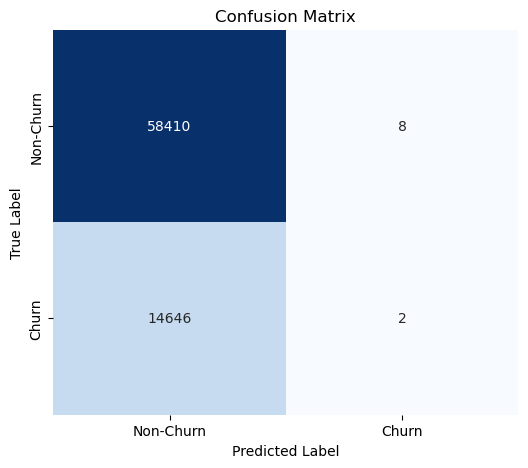

In [325]:
# Get the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a heatmap using seaborn for better visualization
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, 
            xticklabels=["Non-Churn", "Churn"], yticklabels=["Non-Churn", "Churn"])

# Set plot labels and title
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [326]:
# Disply accuracy of the model
accuracy

0.7994416007445323

The accuracy of the model is 80% which means 80 % of the predictions are correct. But relying on accuracy will give false result because model is biased towards the non-churn classes.  Precision for class 0 is 80 % which means chances of identifying the non-churn classes are very high. Recalling value is 1 means the model correctly identify all non-churn customers. Precision for class 1 is very low which 0.17 means chances of identifying the churn customers are very less and the recall value is 0 means model is failed to identify the actual churn customers. From the above result we conclude that accuracy, precision and recall values for class 0 is very good because dataset contains most non-churn customers.

In [327]:
# Use feature importance from the trained Random Forest model
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

Here, the code extracts the feature importances from the trained `RandomForestClassifier` model using its attribute `feature_importances_`, and creates a DataFrame `feature_importance_df` with the feature names and their importance scores in a sorted manner in a descending order to highlight the most influential features in predicting churn.

In [328]:
# Display the top 10 most important features
top_features = feature_importance_df.head(10)

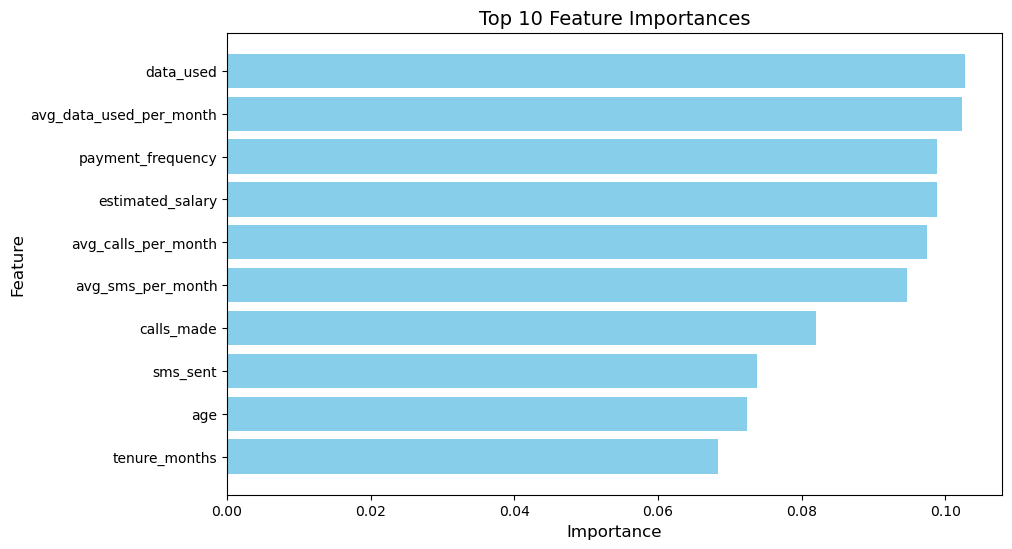

In [329]:
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 10 Feature Importances', fontsize=14)
plt.gca().invert_yaxis()
plt.show()

This code generates a horizontal bar plot to display the top 10 most important features in terms of predicting churn. The 'top_features' DataFrame created above is utilized, with the plt.barh() function used to plot the feature names on the y-axis and their importance on the x-axis. The y-axis is inverted in order to have the most important features at the top, and the plot includes labels and a title for clarity.

In [330]:
# Display feature importance data
top_features

,Feature,Importance
5,data_used,0.102755
9,avg_data_used_per_month,0.102363
11,payment_frequency,0.098885
2,estimated_salary,0.098842
7,avg_calls_per_month,0.097390
8,avg_sms_per_month,0.094708
3,calls_made,0.082054
4,sms_sent,0.073729
0,age,0.072388
6,tenure_months,0.068343


Above table show the top 10 feature that are responsible for customer churn. data_used and avg_data_used_per_month are playing crucial role in predicting the churn. estimated_salary means customer financial profile has moderate impact in predicting the churn. avg_calls_per_month, avg_sms_per_month and age are less likely contributing to predict the customer churn.

This code displays the `top_features` DataFrame, which contains feature names and their corresponding importance scores from the trained `RandomForestClassifier` model. This output points out the most influential features for predicting churn, based on the feature importance values computed by the model.